In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
df = pd.read_csv("../data/raw/vahan_vehicle_registrations.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,_id,id,date,state_name,state_code,office_name,office_code,vehicle_type,category,registrations
0,1,0,2020-04-01T00:00:00,Andaman And Nicobar Islands,35,Port Blair Dto,AN1,Heavy Goods Vehicle,Vehicle Category,8.0
1,2,1,2020-04-01T00:00:00,Andaman And Nicobar Islands,35,Port Blair Dto,AN1,Light Goods Vehicle,Vehicle Category,19.0
2,3,2,2020-04-01T00:00:00,Andaman And Nicobar Islands,35,Port Blair Dto,AN1,Light Motor Vehicle,Vehicle Category,12.0
3,4,3,2020-04-01T00:00:00,Andaman And Nicobar Islands,35,Port Blair Dto,AN1,Light Passenger Vehicle,Vehicle Category,4.0
4,5,4,2020-04-01T00:00:00,Andaman And Nicobar Islands,35,Port Blair Dto,AN1,Other Than Mentioned Above,Vehicle Category,1.0


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 584267
Columns: 10


In [7]:
df.columns

Index(['_id', 'id', 'date', 'state_name', 'state_code', 'office_name',
       'office_code', 'vehicle_type', 'category', 'registrations'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584267 entries, 0 to 584266
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   _id            584267 non-null  int64  
 1   id             584267 non-null  int64  
 2   date           584267 non-null  object 
 3   state_name     584267 non-null  object 
 4   state_code     584267 non-null  int64  
 5   office_name    584267 non-null  object 
 6   office_code    584267 non-null  object 
 7   vehicle_type   584267 non-null  object 
 8   category       584267 non-null  object 
 9   registrations  584267 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 44.6+ MB


In [9]:
df.isnull().sum()

_id              0
id               0
date             0
state_name       0
state_code       0
office_name      0
office_code      0
vehicle_type     0
category         0
registrations    0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
df["date"] = pd.to_datetime(df["date"])

In [12]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Start date: 2019-01-01 00:00:00
End date: 2024-05-01 00:00:00


In [13]:
vehicle_counts = df["vehicle_type"].value_counts()

print(vehicle_counts)

vehicle_type
Light Motor Vehicle                80350
Two Wheeler(Nt)                    79922
Light Goods Vehicle                66569
Three Wheeler(T)                   56508
Light Passenger Vehicle            55758
Heavy Goods Vehicle                55418
Other Than Mentioned Above         45617
Medium Goods Vehicle               37404
Medium Motor Vehicle               24744
Medium Passenger Vehicle           23708
Heavy Passenger Vehicle            17200
Heavy Motor Vehicle                12561
Two Wheeler (Invalid Carriage)     11410
Four Wheeler (Invalid Carriage)     8277
Three Wheeler(Nt)                   4985
Two Wheeler(T)                      3836
Name: count, dtype: int64


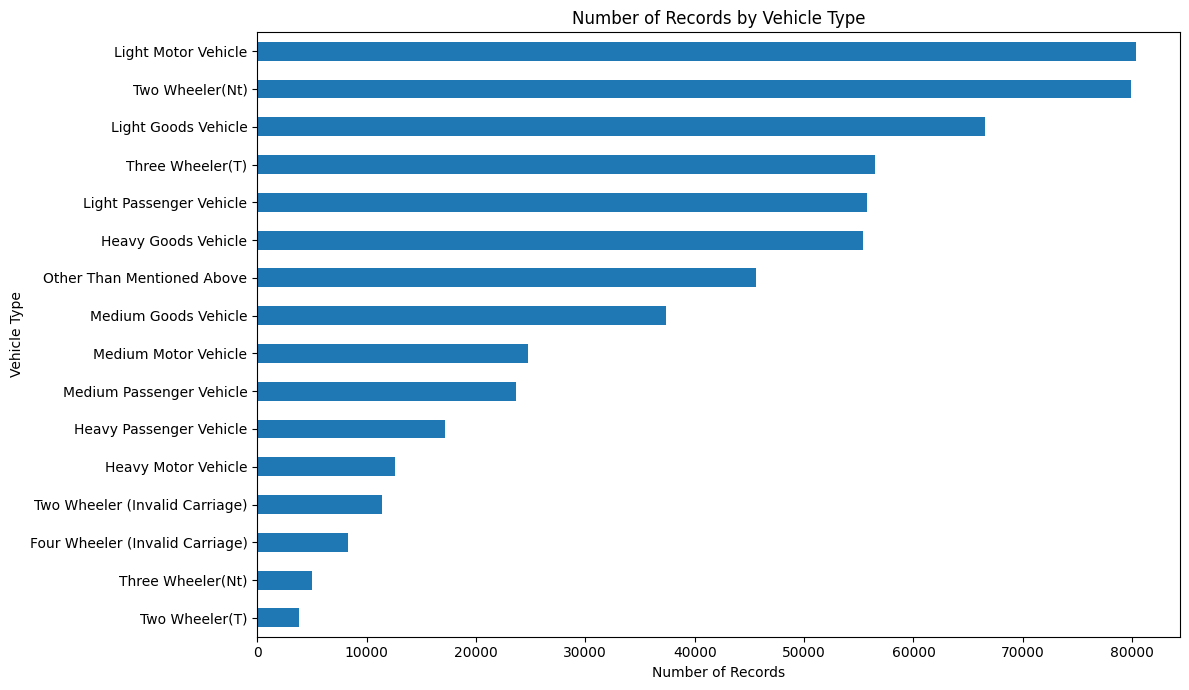

In [14]:
plt.figure(figsize=(12, 7))

vehicle_counts.sort_values().plot(kind="barh")

plt.title("Number of Records by Vehicle Type")
plt.xlabel("Number of Records")
plt.ylabel("Vehicle Type")

plt.tight_layout()
plt.show()

In [15]:
states = df["state_name"].unique()

print("Number of states/UTs:", len(states))
print("\nStates/UTs:")
for state in sorted(states):
    print(state)

Number of states/UTs: 34

States/UTs:
Andaman And Nicobar Islands
Andhra Pradesh
Arunachal Pradesh
Assam
Bihar
Chandigarh
Chhattisgarh
Delhi
Goa
Gujarat
Haryana
Himachal Pradesh
Jammu And Kashmir
Jharkhand
Karnataka
Kerala
Ladakh
Madhya Pradesh
Maharashtra
Manipur
Meghalaya
Mizoram
Nagaland
Odisha
Puducherry
Punjab
Rajasthan
Sikkim
Tamil Nadu
The Dadra And Nagar Haveli And Daman And Diu
Tripura
Uttar Pradesh
Uttarakhand
West Bengal


In [16]:
state_registrations = (
    df.groupby("state_name")["registrations"]
      .sum()
      .sort_values(ascending=False)
)

state_registrations.head(15)

state_name
Andhra Pradesh       157960221.0
Tamil Nadu           139599930.0
Rajasthan             87937973.0
Arunachal Pradesh     83242443.0
Kerala                63250609.0
Punjab                41000076.0
Madhya Pradesh        26931559.0
Bihar                 24909621.0
West Bengal           24215553.0
Delhi                 19538600.0
Himachal Pradesh      19313888.0
Uttar Pradesh         16845359.0
Maharashtra           12123835.0
Gujarat                8106553.0
Karnataka              8041037.0
Name: registrations, dtype: float64

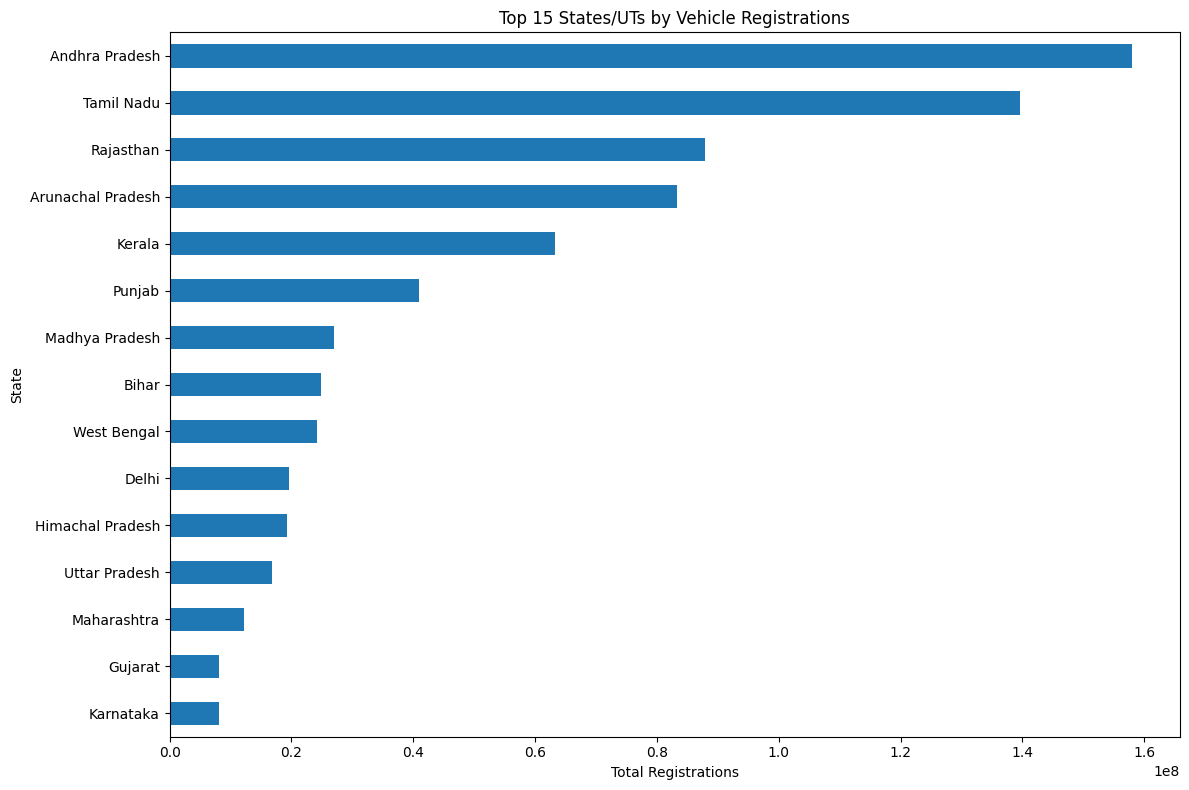

In [17]:
plt.figure(figsize=(12, 8))

state_registrations.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 States/UTs by Vehicle Registrations")
plt.xlabel("Total Registrations")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [18]:
vehicle_registrations = (
    df.groupby("vehicle_type")["registrations"]
      .sum()
      .sort_values(ascending=False)
)

vehicle_registrations

vehicle_type
Two Wheeler(Nt)                    564249065.0
Light Motor Vehicle                133354415.0
Light Goods Vehicle                 19803961.0
Three Wheeler(T)                    19708335.0
Heavy Goods Vehicle                  6500802.0
Light Passenger Vehicle              5184433.0
Other Than Mentioned Above           1763596.0
Medium Goods Vehicle                 1189641.0
Heavy Passenger Vehicle               622030.0
Medium Motor Vehicle                  580276.0
Medium Passenger Vehicle              459019.0
Two Wheeler (Invalid Carriage)        457202.0
Three Wheeler(Nt)                     442967.0
Two Wheeler(T)                        380061.0
Heavy Motor Vehicle                   176943.0
Four Wheeler (Invalid Carriage)        75379.0
Name: registrations, dtype: float64

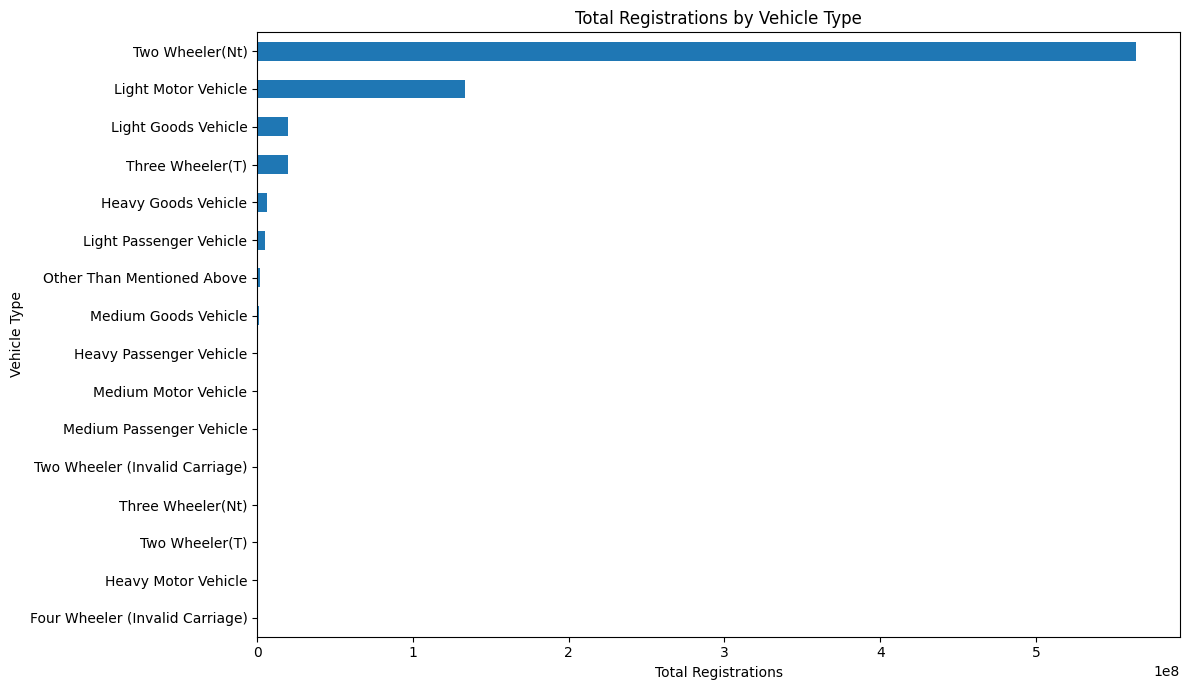

In [19]:
plt.figure(figsize=(12, 7))

vehicle_registrations.sort_values().plot(kind="barh")

plt.title("Total Registrations by Vehicle Type")
plt.xlabel("Total Registrations")
plt.ylabel("Vehicle Type")

plt.tight_layout()
plt.show()

In [20]:
df["category"].value_counts()

category
Vehicle Category    584267
Name: count, dtype: int64

In [21]:
state_vehicle = (
    df.groupby(["state_name", "vehicle_type"])["registrations"]
      .sum()
      .reset_index()
)

state_vehicle.head(20)

,state_name,vehicle_type,registrations
0,Andaman And Nicobar Islands,Four Wheeler (Invalid Carriage),1.0
1,Andaman And Nicobar Islands,Heavy Goods Vehicle,411.0
2,Andaman And Nicobar Islands,Heavy Motor Vehicle,13.0
3,Andaman And Nicobar Islands,Heavy Passenger Vehicle,93.0
4,Andaman And Nicobar Islands,Light Goods Vehicle,1011.0
5,Andaman And Nicobar Islands,Light Motor Vehicle,8469.0
6,Andaman And Nicobar Islands,Light Passenger Vehicle,914.0
7,Andaman And Nicobar Islands,Medium Goods Vehicle,49.0
8,Andaman And Nicobar Islands,Medium Motor Vehicle,25.0
9,Andaman And Nicobar Islands,Medium Passenger Vehicle,10.0
